In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "16"

In [2]:
# Initialise dask cluster
from dask.distributed import Client, LocalCluster
cluster = LocalCluster(n_workers=4, threads_per_worker=4, memory_limit="16GB")
client = Client(cluster)
client

/home/papa/_venvs/notes_py311/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33357 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:33357/status,
Dashboard: http://127.0.0.1:33357/status,Workers: 4
Total threads: 16,Total memory: 59.60 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37629,Workers: 0
Dashboard: http://127.0.0.1:33357/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34189,Total threads: 4
Dashboard: http://127.0.0.1:34001/status,Memory: 14.90 GiB
Nanny: tcp://127.0.0.1:35893,


In [3]:
data_grid = "O200"
date = "2017-01-21"
import src.main.fetch as fetch
from src.main.config import digest_config
digest_config()

model_files = f"./data/era5/era5_ecrad_{date}_{data_grid}_*_zarr"

Using default value for ghg_file: greenhouse_gas_timeseries_CMIP6_SSP370_CFC11equiv_47r1.nc
Using default value for cams_clim_file: aerosol_cams_climatology_49r2_1951-2019_4D.nc
Using default value for aeosol_optics_version: 49r1
Using default value for tot_solar_irr_file: total_solar_irradiance_CMIP6_49r1.nc
Using default value for nml_template: config_flotsam_template.nam
Successfully read configuration from None


In [4]:
import numpy as np
model_fields = fetch.model_fields(model_files=model_files)

# Dask-parallel chunking: 8 time chunks x 4 col chunks = 32 independent tasks.
if "col" in model_fields.dims:
    col_chunk = -1 # int(np.ceil(len(model_fields.col) / 4))
    model_fields = model_fields.chunk({"time": 1, "col": col_chunk})

model_fields

Opening archives as zarr
Using all model times
Computing sp from lnsp
Variables in model_fields: 10u, 10v, fal, lat, lsm, reduced_points, skt, tcc, time, tisr, tsr, tsrc, cc, ciwc, clwc, crwc, cswc, hyai, hyam, hybi, hybm, lev, lev_2, lnsp, o3, q, t, sp, p, p_half


<xarray.Dataset> Size: 7GB
Dimensions:         (time: 8, col: 167200, lev: 137, nhyi: 138, nhym: 137,
                     lev_2: 1, half_lev: 138, lat: 400)
Coordinates:
  * lat             (lat) float64 3kB 89.66 89.21 88.76 ... -88.76 -89.21 -89.66
    reduced_points  (lat) int32 2kB dask.array<chunksize=(400,), meta=np.ndarray>
  * time            (time) datetime64[ns] 64B 2017-01-21T12:00:00 ... 2017-01...
  * lev             (lev) float64 1kB 1.0 2.0 3.0 4.0 ... 135.0 136.0 137.0
  * lev_2           (lev_2) float64 8B 1.0
Dimensions without coordinates: col, nhyi, nhym, half_lev
Data variables: (12/25)
    10u             (time, col) float32 5MB dask.array<chunksize=(1, 167200), meta=np.ndarray>
    10v             (time, col) float32 5MB dask.array<chunksize=(1, 167200), meta=np.ndarray>
    fal             (time, col) float32 5MB dask.array<chunksize=(1, 167200), meta=np.ndarray>
    lsm             (time, col) float32 5MB dask.array<chunksize=(1, 167200), meta=np.ndarray>
    skt             (time, col) float32 5MB dask.array<chunksize=(1, 167200), meta=np.ndarray>
    tcc             (time, col) float32 5MB dask.array<chunksize=(1, 167200), meta=np.ndarray>
    ...              ...
    o3              (time, lev, col) float32 733MB dask.array<chunksize=(1, 137, 167200), meta=np.ndarray>
    q               (time, lev, col) float32 733MB dask.array<chunksize=(1, 137, 167200), meta=np.ndarray>
    t               (time, lev, col) float32 733MB dask.array<chunksize=(1, 137, 167200), meta=np.ndarray>
    sp              (time, col) float32 5MB dask.array<chunksize=(1, 167200), meta=np.ndarray>
    p               (time, col, lev) float32 733MB dask.array<chunksize=(1, 167200, 137), meta=np.ndarray>
    p_half          (time, col, half_lev) float32 738MB dask.array<chunksize=(1, 167200, 138), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.5.3 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Wed May 13 15:22:46 2026: cdo --eccodes -f nc4 copy ./era5/...
    CDO:          Climate Data Operators version 2.5.3 (https://mpimet.mpg.de...

In [5]:
import cProfile, pstats
import time
start=time.time()
with cProfile.Profile() as pr:
    aerosol_fields = fetch.aerosol_clim(model_data=model_fields, model_pres_var="p")
print(f"Took {time.time()-start:.1f}s")
pstats.Stats(pr).sort_stats("cumtime").print_stats(50)

Interp_2d using 16 threads
Interp_2d using 16 threads
 Running interp in single precision
Took 16.8s
         242560 function calls (235945 primitive calls) in 16.775 seconds

   Ordered by: cumulative time
   List reduced from 1940 to 50 due to restriction <50>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.199    0.199   16.775   16.775 /etc/ecmwf/nfs/dh1_home_b/papa/Documents/ecradoff/src/main/fetch.py:132(aerosol_clim)
        1    0.145    0.145   14.286   14.286 /etc/ecmwf/nfs/dh1_home_b/papa/Documents/ecradoff/src/interp/wrapper.py:319(interp3d_to)
        1    0.074    0.074    9.875    9.875 /etc/ecmwf/nfs/dh1_home_b/papa/Documents/ecradoff/src/interp/wrapper.py:381(interpvert_to)
        1    0.000    0.000    5.281    5.281 /etc/ecmwf/nfs/dh1_home_b/papa/Documents/ecradoff/src/interp/verticals.py:59(interp_fld)
        1    4.743    4.743    5.281    5.281 /etc/ecmwf/nfs/dh1_home_b/papa/Documents/ecradoff/src/interp/interface.py:202(i

In [6]:
ghg_data = fetch.ghg_data(model_times=model_fields["time"])

In [7]:
from src.main.config import get_tsirr_path, SENSOR_GEOSTATIONARY, SENSOR_LAT_DEG_N, SENSOR_LON_DEG_E
from src.tools.eot import Irradiance, cos_satza_deg, sat_azimuthrad_deg
ThisIrr = Irradiance(date=aerosol_fields.data.profile.array.time,
                     solar_irr_path=get_tsirr_path())

In [8]:
map_lons = aerosol_fields.data.profile.grid.xa_lon
map_lats = aerosol_fields.data.profile.grid.xa_lat
cos_sza = ThisIrr.mu0_cos_sza_deg(
    phi=map_lats,
    lam=map_lons, night_to_zero=True)
solar_irr = ThisIrr.solar_irr
if SENSOR_GEOSTATIONARY:

    sun_azimuth = ThisIrr.azimuthrad_deg(
        phi=map_lats,
        lam=map_lons)
    cos_satza = cos_satza_deg(sat_phi=SENSOR_LAT_DEG_N, sat_lam=SENSOR_LON_DEG_E,
                              phi=map_lats,
                              lam=map_lons)
    sat_azimuth = sat_azimuthrad_deg(
        sat_phi=SENSOR_LAT_DEG_N, sat_lam=SENSOR_LON_DEG_E,
        phi=map_lats,
        lam=map_lons)
else:
    sun_azimuth = None
    cos_satza = None
    sat_azimuth = None
    
    

In [9]:
import f90nml
from src.main.config import get_nml_template_path
with open(get_nml_template_path().replace(".nml", ".nam"), "r") as fnml:
    nml_template = f90nml.read(fnml)

from typing import Tuple

def process_nml(nml_template : f90nml.Namelist,
                aerosol_indexes : Tuple[int]) -> f90nml.Namelist:
    """Example function to process the namelist template."""
    import copy
    # Accessing a specific section and variablie
    var_to_pop = {
        "radiation_driver": [
            "solar_latitude",
            "solar_longitude",
            "sensor_latitude",
            "sensor_longitude",
            "solar_irradiance_override",
        ],
        "radiation" : [
            "sw_albedo_wavelength_bound",
            "i_sw_albedo_index"
        ]
    }
    # Meteosat-11 (9.5E, 0.0N)
    var_to_update = {
        "radiation_driver": {
            "iverbose" : 1,
            #"nblocksize" : 512,
            # "sensor_latitude": SENSOR_LAT_DEG_N,
            # "sensor_longitude": SENSOR_LON_DEG_E,
        },
        "radiation" : {
            "iverbose" : 1,
            "n_cloudy_subcolumns_sw" : 2,
            "i_aerosol_type_map" : list(aerosol_indexes)
        }
    }
    nml_out = copy.deepcopy(nml_template)
    for section, vars in var_to_pop.items():
        for var in vars:
            if var in nml_template[section]:
                nml_out[section].pop(var)
    for section, vars in var_to_update.items():
        for var, value in vars.items():
            nml_out[section][var] = value
    return nml_out

In [10]:
from src.ecrad.packer import gen_ecrad_dset
import xarray as xr

tmp_root = os.environ.get("ECRADOFF_TMP", None) or os.environ.get("TMPDIR", None)

import tempfile
tmp_ecrad = tempfile.TemporaryDirectory(dir=tmp_root)
print(tmp_ecrad)
cmd = "for i in {0.."+f"{len(model_fields.time)-1}"+"}; do OMP_NUM_THREADS=16 ./ecrad ecrad_flotsam_000${i}.nam ecrad_input_000${i}.nc ecrad_output_000${i}.nc; done"
print(cmd, flush=True)

if not os.path.exists(os.path.join(tmp_ecrad.name, "data")):
    # create symlink to ecrad/data
    from src.main.config import ECRAD_DATA_DIR
    os.symlink(ECRAD_DATA_DIR, os.path.join(tmp_ecrad.name, "data"))
if not os.path.exists(os.path.join(tmp_ecrad.name, "ecrad")):
    # create symlink to ecrad
    from src.main.config import ECRAD_DIR
    os.symlink(os.path.join(ECRAD_DIR, "bin/ecrad"), os.path.join(tmp_ecrad.name, "ecrad"))

assert(isinstance(cos_sza, xr.DataArray))
assert(isinstance(solar_irr, xr.DataArray))

from src.main.fetch import cast_floats

groups = []
for tstep in range(2):
    if cos_satza is not None:
        this_cos_satza = cos_satza.isel(time=tstep) if "time" in cos_satza.dims else  cos_satza
        this_cos_satza = cos_satza
    else:
        this_cos_satza = None

    if sat_azimuth is not None:
        this_sat_azimuth = sat_azimuth.isel(time=tstep) if "time" in sat_azimuth.dims else  sat_azimuth
        this_sat_azimuth = sat_azimuth
    else:
        this_sat_azimuth = None

    if sun_azimuth is not None:
        this_sun_azimuth = sun_azimuth.isel(time=tstep)
    else:
        this_sun_azimuth = None

    ecrad_dset = gen_ecrad_dset(model_fields=model_fields.isel(time=tstep),
                                cos_sza=cos_sza.isel(time=tstep),
                                solar_irradiance=solar_irr.isel(time=tstep).values.item(),
                                aerosol_mmr=aerosol_fields.data.profile.array["aerosol_mmr"].isel(time=tstep),
                                ghg_data=ghg_data.isel(time=tstep),
                                grid_desc=aerosol_fields.data.profile.grid,
                                cos_satza=this_cos_satza,
                                sun_azimuth=this_sun_azimuth,
                                sat_azimuth=this_sat_azimuth
                                )
    ecrad_dset = ecrad_dset.assign_coords(
        lon_full=aerosol_fields.data.profile.grid.xa_lon,
        lat_full=aerosol_fields.data.profile.grid.xa_lat,
        time=model_fields.time.isel(time=tstep)
        )

    print("Calculating ecrad_dset", flush=True)
    ecrad_dset = cast_floats(ecrad_dset).compute()
    # ecrad_dset["re_liquid"] = ecrad_dset["re_liquid"].clip(min=10.e-6, max=20.e-6)
    # ecrad_dset["re_ice"] = ecrad_dset["re_ice"].clip(min=50.e-6, max=100.e-6)
    # #ecrad_dset["cloud_fraction"] = ecrad_dset["cloud_fraction"].clip(min=0.9, max=0.9)
    #ecrad_dset["q_liquid"] = ecrad_dset["q_liquid"]
    #ecrad_dset["q_ice"] = ecrad_dset["q_ice"]
    #ecrad_dset["tcc"] = ecrad_dset["tcc"].clip(min=1.0, max=1.0)
    # ecrad_dset["iseed"] = ecrad_dset["iseed"].clip(min=5, max=5)


    ## OVERLAP ANGLES FAILS
    # ecrad_dset["sensor_azimuth_angle"] = ecrad_dset["sensor_azimuth_angle"].clip(min=0.3, max=0.3)
    # ecrad_dset["solar_azimuth_angle"] = ecrad_dset["solar_azimuth_angle"].clip(min=0.7, max=0.7)
    # ecrad_dset["cos_sensor_zenith_angle"] = ecrad_dset["cos_sensor_zenith_angle"].clip(min=0.5, max=0.5)
    # ecrad_dset["cos_solar_zenith_angle"] = ecrad_dset["cos_solar_zenith_angle"].clip(min=0.3, max=0.3)

    # ecrad_dset["o3_mmr"] = ecrad_dset["o3_mmr"].clip(min=3.e-8, max=3.e-8)
    # ecrad_dset["h2o_mmr"] = ecrad_dset["h2o_mmr"].clip(min=1.e-6, max=1.e-6)
    # ecrad_dset["aerosol_mmr"]  = ecrad_dset["aerosol_mmr"].clip(min=0.0, max=0.0)
    # ecrad_dset["pressure_hl"] = ecrad_dset["pressure_hl"].clip(min=1.e-2)
    # ecrad_dset["sw_albedo"] = ecrad_dset["sw_albedo"].clip(min=0.4, max=0.4)
    # ecrad_dset["skin_temperature"] = ecrad_dset["skin_temperature"].clip(min=300.0, max=300.0)

    # Drop all coordinate variables NOt needed
    # ecrad_dset = ecrad_dset.drop_vars([var for var in ecrad_dset.coords])

    infile = os.path.join(tmp_ecrad.name, f"ecrad_input_{tstep:04d}.nc")
    outfile = os.path.join(tmp_ecrad.name, f"ecrad_output_{tstep:04d}.nc")
    namfile = os.path.join(tmp_ecrad.name, f"ecrad_flotsam_{tstep:04d}.nam")


    ecrad_dset.to_netcdf(
        infile,
        format="NETCDF4_CLASSIC"
        )
    
    nml_out = process_nml(nml_template,
            aerosol_fields.optics_idx)
    with open(namfile, "w") as fnml:
        f90nml.write(nml_out, fnml)
    
    groups.append((infile, namfile, outfile))



#{"Aerosols maps" : {var: idx for var, idx in zip(aerosol_mmr.optics_var, aerosol_mmr.optics_idx)},

<TemporaryDirectory '/etc/ecmwf/ssd/ssd1/ecinteractive/papa-ecinteractive/tmpdirs/papa.31396347/tmpk59g07yn'>
for i in {0..7}; do OMP_NUM_THREADS=16 ./ecrad ecrad_flotsam_000${i}.nam ecrad_input_000${i}.nc ecrad_output_000${i}.nc; done


Calculating ecrad_dset
Calculating ecrad_dset


Now run ecRad
========
```
$ cd <tmpdir>
$ for i in {0..1}; do OMP_NUM_THREADS=16 ./ecrad ecrad_flotsam_000${i}.nam ecrad_input_000${i}.nc ecrad_output_000${i}.nc; done
```

In [16]:
from src.interp.grids import GridType

# We reinterpolate from the flattened (either regular or reduced) grid to a regular grid
dgrid = 0.25
tgt_grid = xr.Dataset(
    coords={
        "lon": ("lon", np.arange(0, 360, dgrid)),
        "lat": ("lat", np.arange(90+dgrid, -90, -dgrid))
    }
).coords

all_ds = []
for group in groups:
    infile, _, outfile = group
    try:
        out_ds = xr.open_dataset(outfile).rename(column="col")
        inp_ds = xr.open_dataset(infile)
        if aerosol_fields.data.profile.grid.gtyp == GridType.REGULAR:
            import cf_xarray as cfxr
            col_decoded = cfxr.decode_compress_to_multi_index(inp_ds).col
            out_ds = out_ds.assign_coords({"col": col_decoded}).unstack("col")
        else:
            out_ds = out_ds.assign_coords(
            {k: ("lat", inp_ds[k].values) for k in ["lat", "reduced_points"]})
        all_ds.append(out_ds.assign_coords(time=inp_ds.time.values))
        del out_ds
    except Exception as e:
        print(f"Failed to open {outfile}: {e}")
datadims = aerosol_fields.data.profile.grid.datadims

out_ds = xr.concat(all_ds, dim="time")

from src.interp.wrapper import GriddedArray
out_ds = GriddedArray(out_ds, datadims=datadims).interp2d_to(tgt_grid=tgt_grid, tgt_datadims=["lat", "lon"]).array


Interp_2d using 16 threads
Interp_2d using 16 threads
Interp_2d using 16 threads


/etc/ecmwf/ssd/ssd1/ecinteractive/papa-ecinteractive/tmpdirs/papa.31396347/ipykernel_2981689/2591153451.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Grays_r").copy()


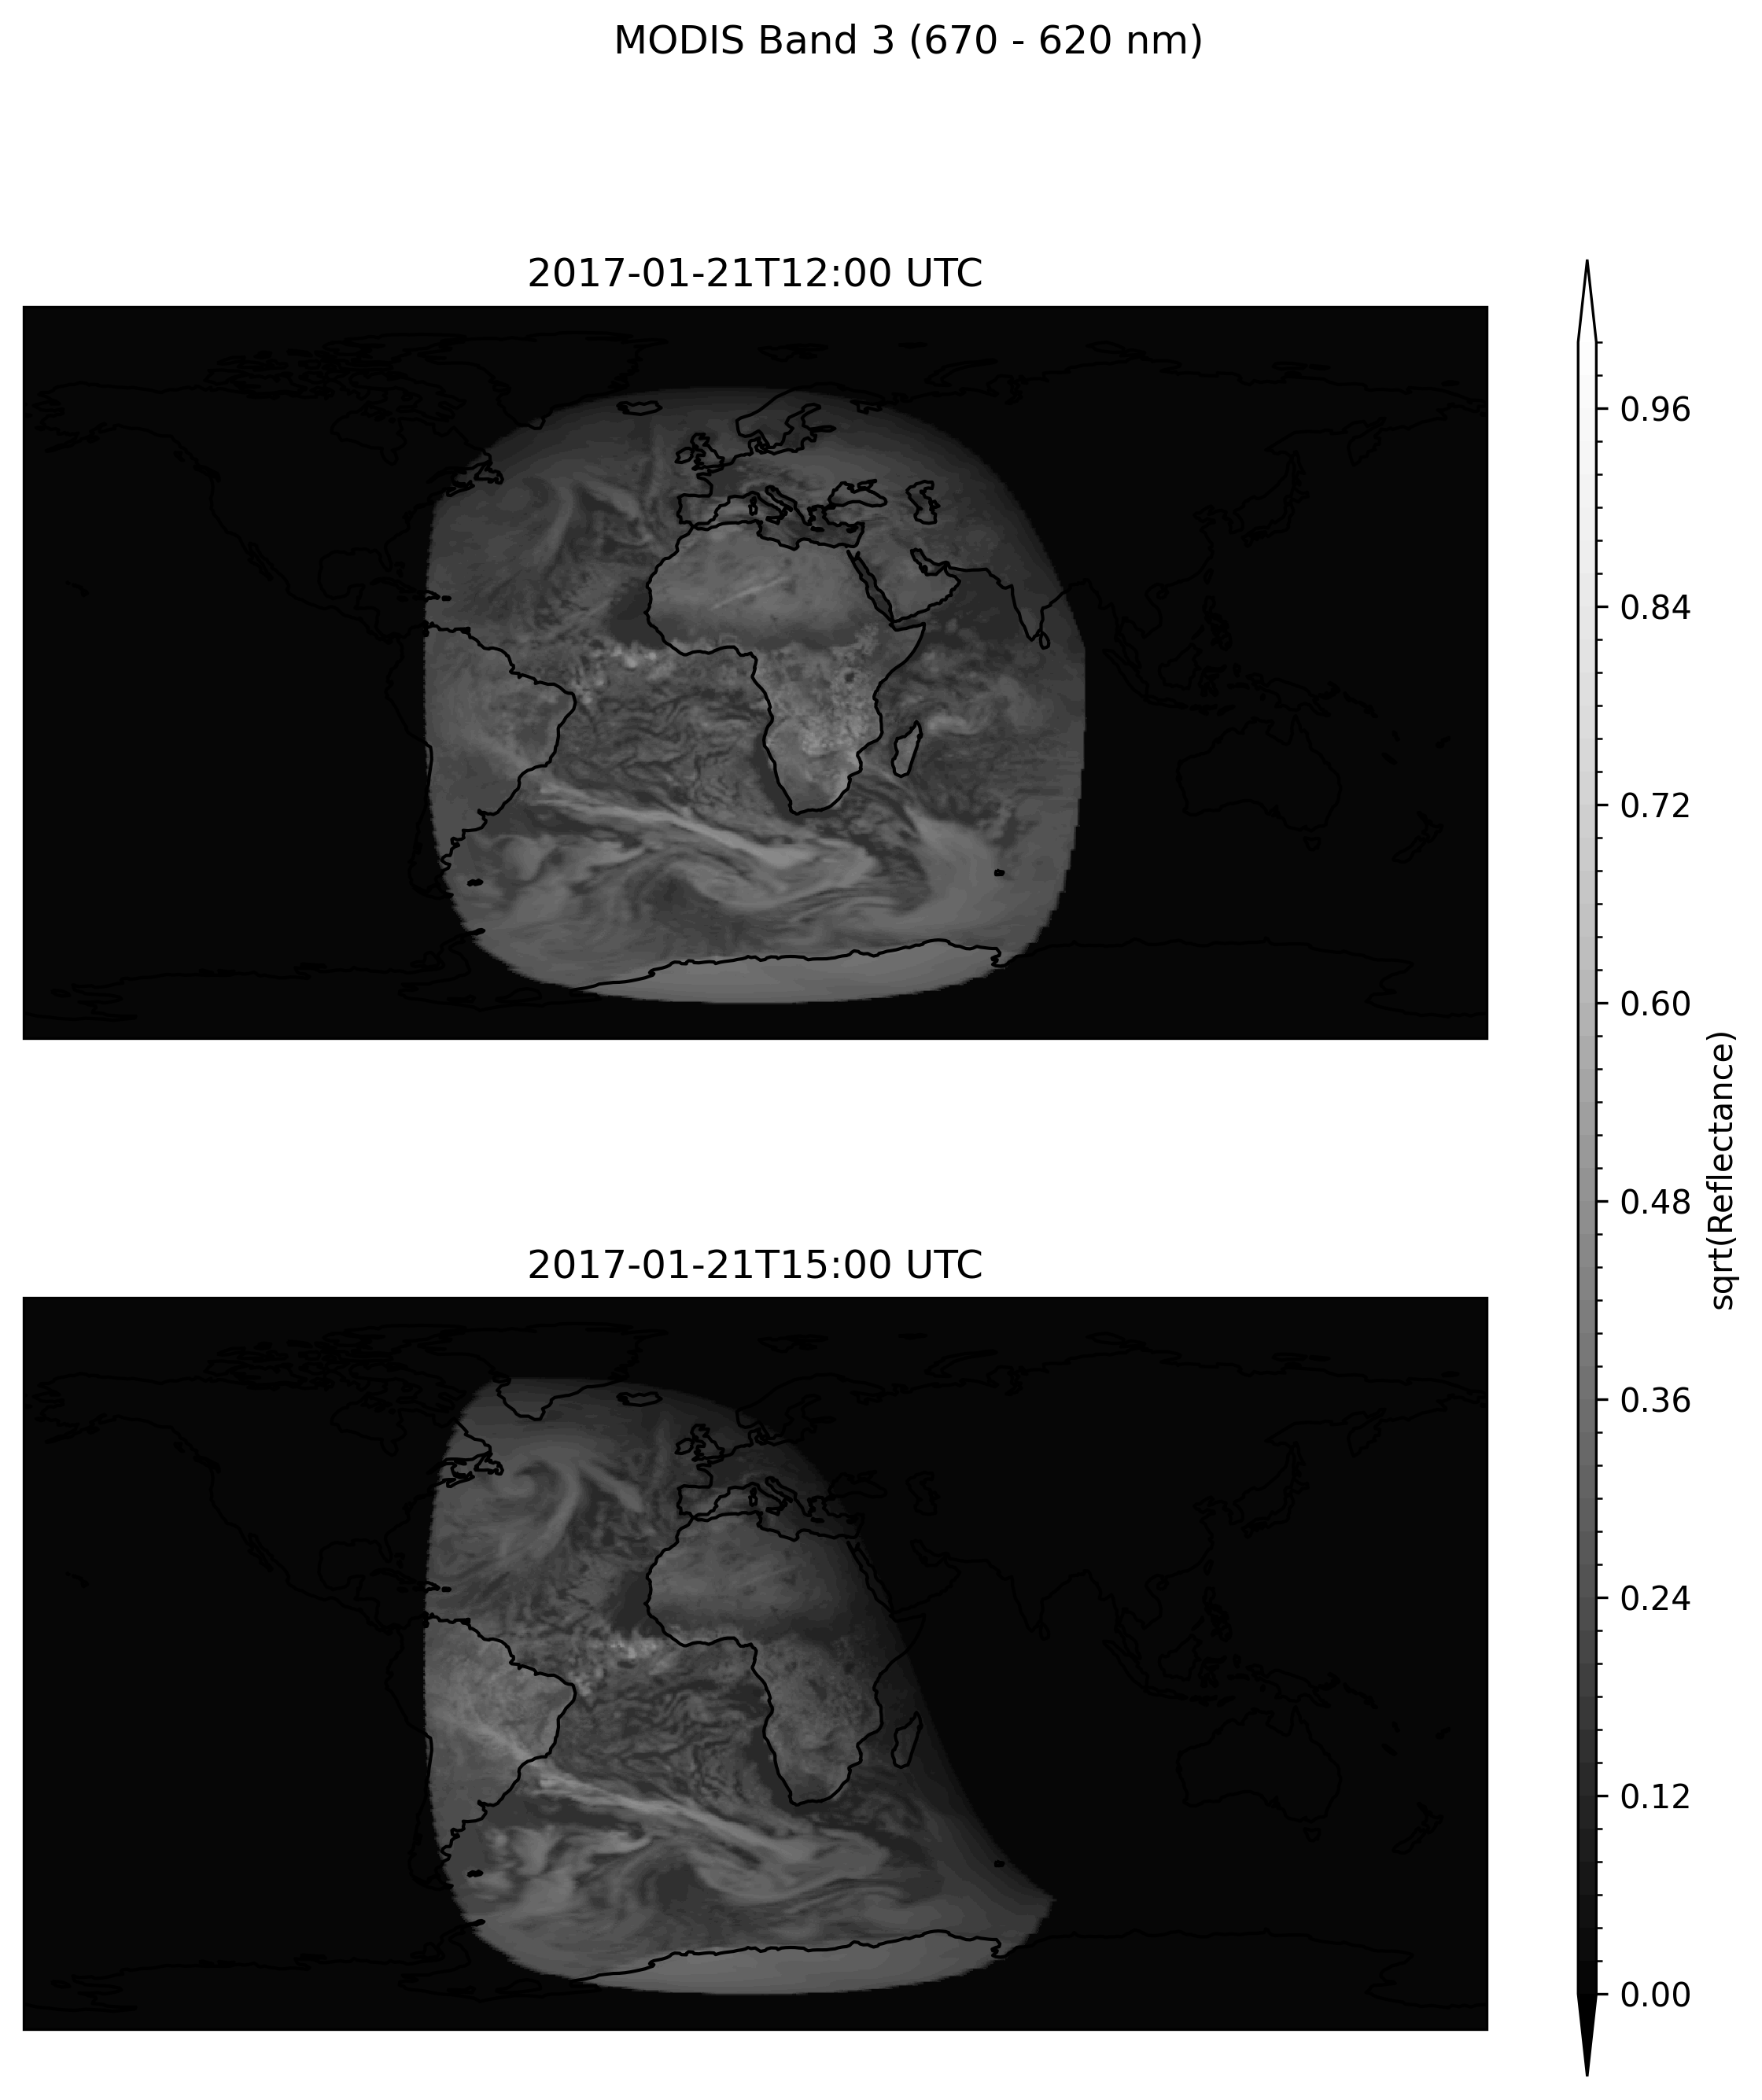

In [20]:
import matplotlib.pyplot as plt
from cartopy import crs as ccrs
sat_proj = ccrs.Geostationary(central_longitude=SENSOR_LON_DEG_E)

tidx = 2

band_sw = 3
fig, axs = plt.subplots(figsize=(10,10), dpi=300, nrows=2,
                       subplot_kw={"projection": ccrs.PlateCarree(central_longitude=SENSOR_LON_DEG_E)})

cmap = plt.cm.get_cmap("Grays_r").copy()
levels = np.linspace(0, 1, 51)
from matplotlib.colors import BoundaryNorm
norm = BoundaryNorm(levels, ncolors=cmap.N, extend="both")

for tidx, ax in enumerate(axs):
    this_out_ds = out_ds.isel(time=tidx).sel(band_sw=band_sw)
    ax.coastlines()
    pcm = ax.pcolormesh(this_out_ds["lon"], this_out_ds["lat"],
                        np.sqrt(this_out_ds["radiance_sw_band"]),
                        transform=ccrs.PlateCarree(),
                    cmap=cmap, norm=norm)
    ax.set_title(str(this_out_ds.time.values)[0:16]+" UTC")
    

# From cm-1 to nm
band1_nm = 1.e7/this_out_ds["wavenumber1_sw"].values.item()
band2_nm = 1.e7/this_out_ds["wavenumber2_sw"].values.item()
fig.suptitle(f"MODIS Band {band_sw} ({band1_nm:.0f} - {band2_nm:.0f} nm)")
plt.colorbar(pcm, ax=axs, label="sqrt(Reflectance)", aspect=100)

## RGB composites

Band 3: 670 - 620 nm
Band 2: 565 - 545 nm
Band 1: 479 - 457 nm


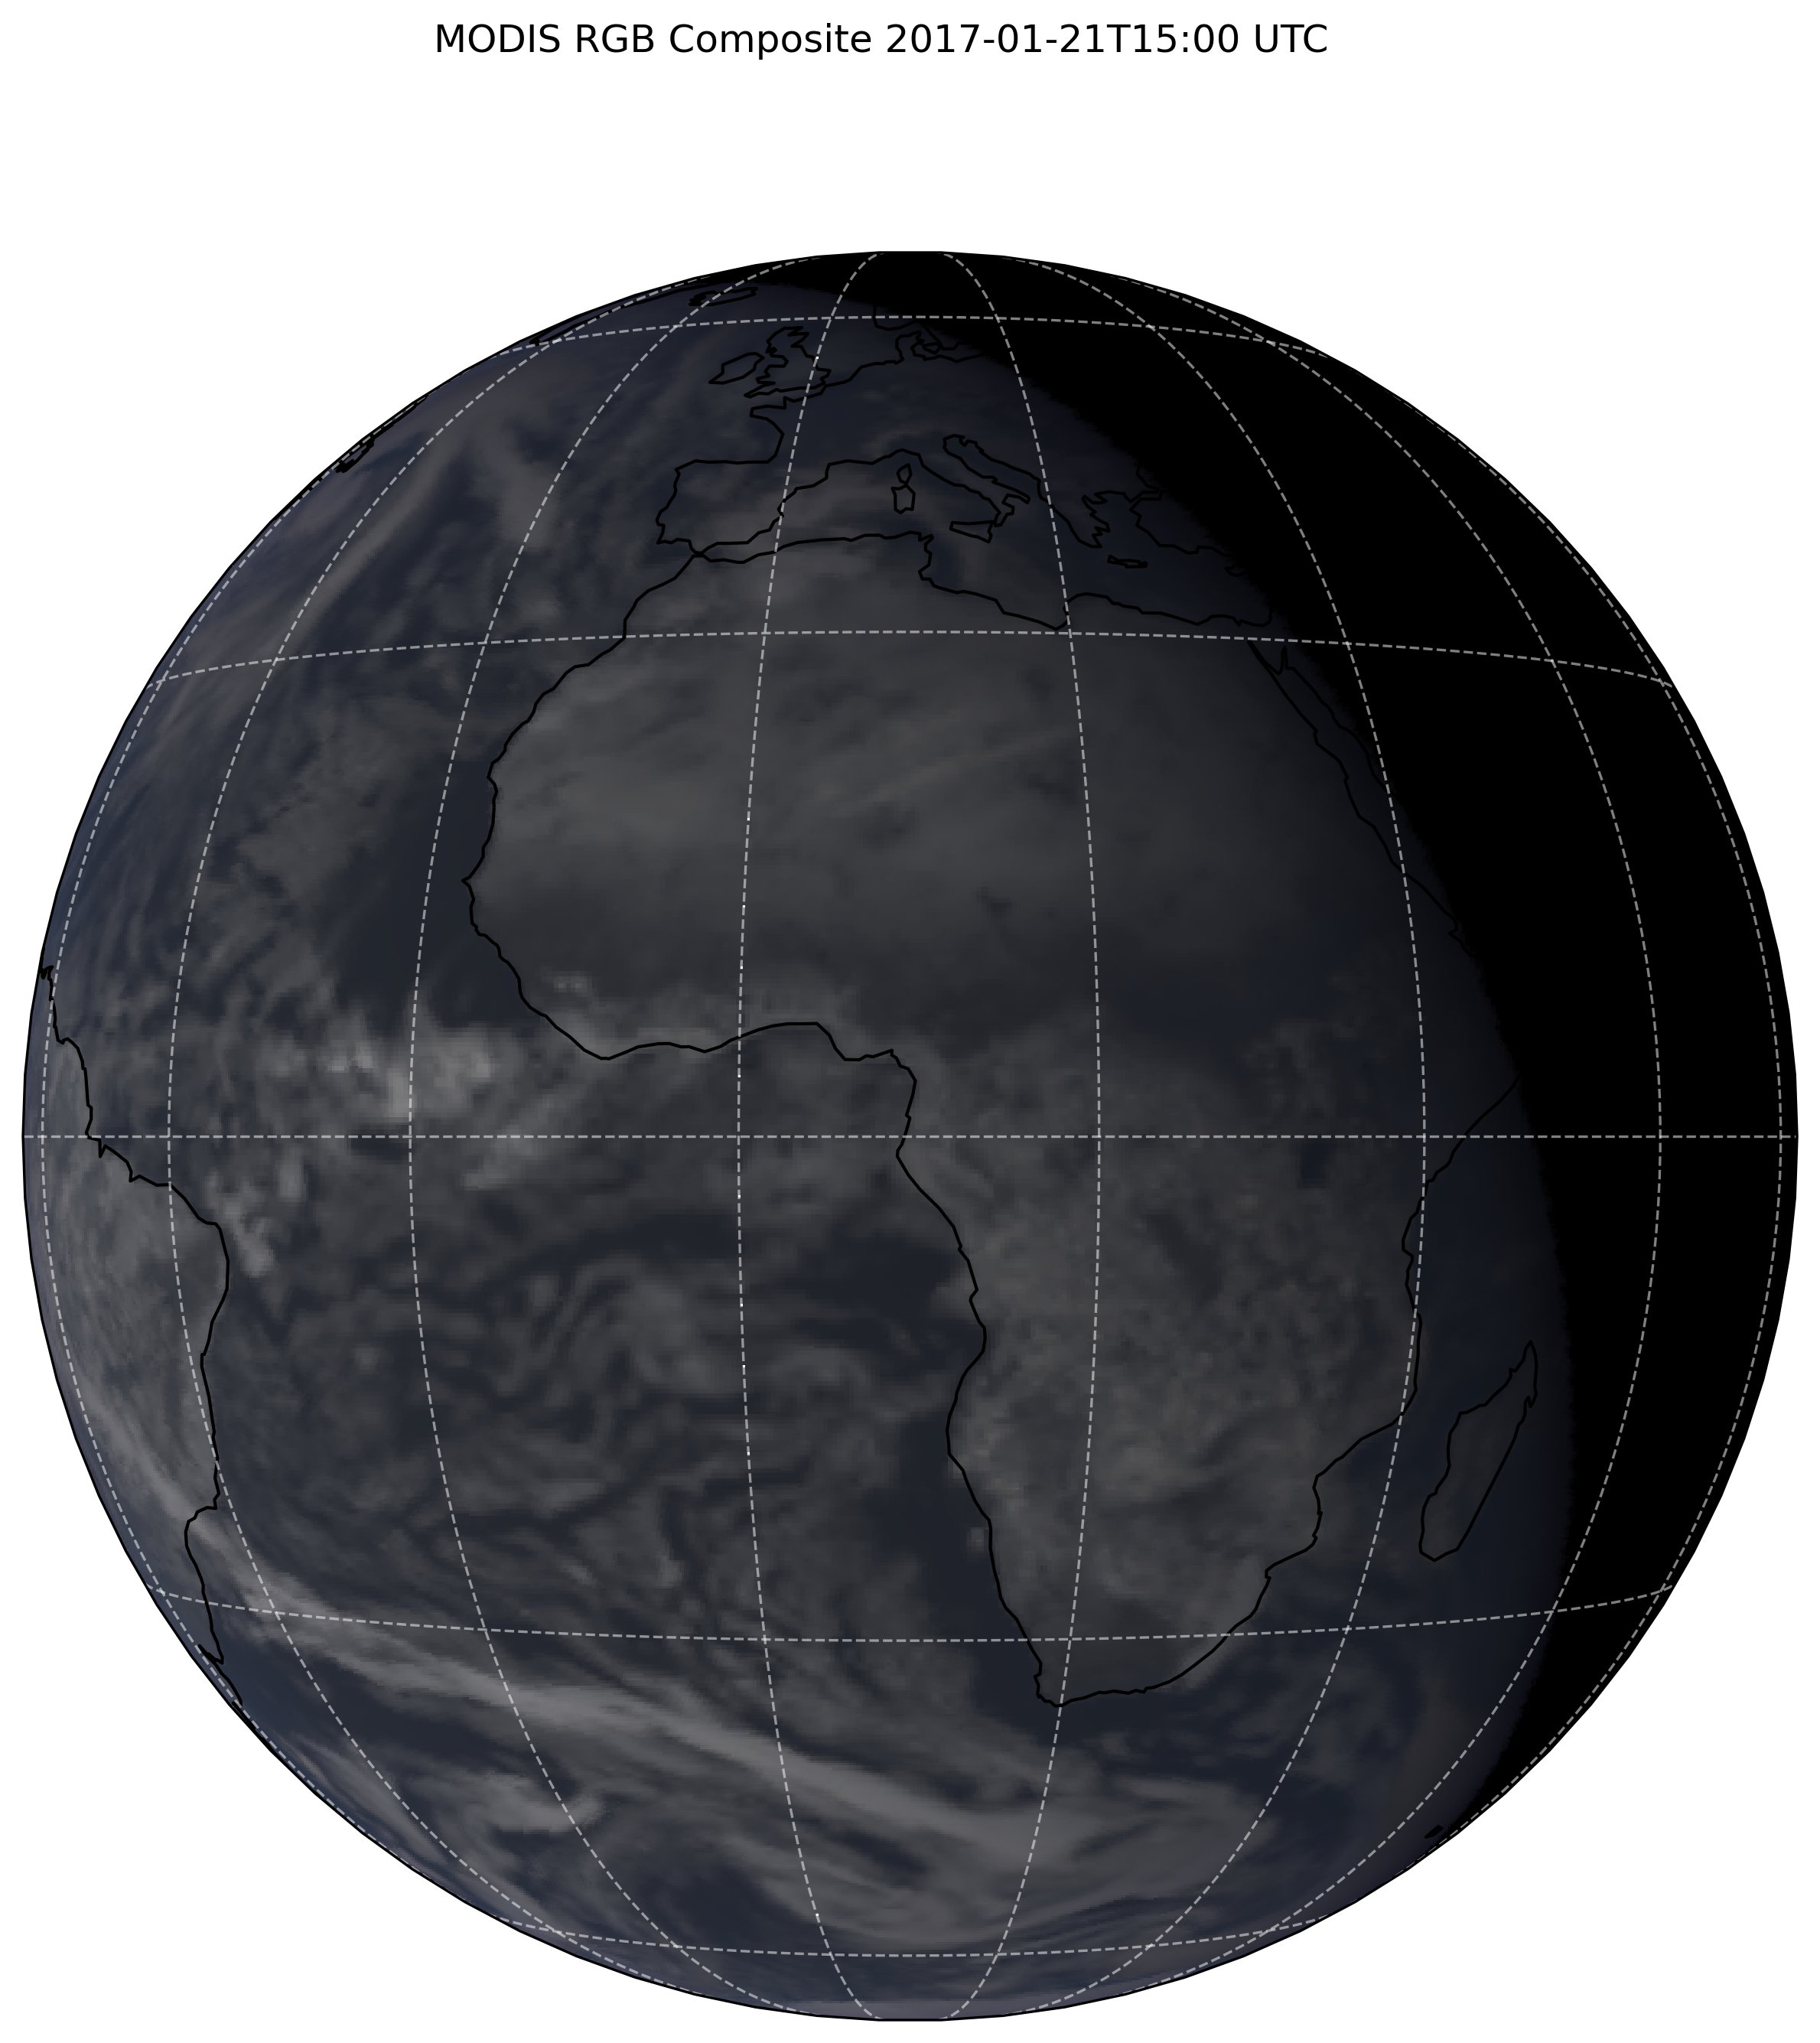

In [21]:
import matplotlib.pyplot as plt
from matplotlib import colormaps as mpl_cm
from cartopy import crs as ccrs

from src.main.config import SENSOR_LON_DEG_E
sat_proj = ccrs.Geostationary(central_longitude=SENSOR_LON_DEG_E)

tidx = 1
rgb_bands = [3, 2, 1]

# Use band labels explicitly (consistent with earlier cells).
this_out_ds = out_ds.isel(time=tidx).sel(band_sw=rgb_bands)

#sat_proj = ccrs.PlateCarree()  # ccrs.Geostationary(central_longitude=SENSOR_LON_DEG_E)
fig, ax = plt.subplots(figsize=(10, 10), dpi=300, subplot_kw={"projection": sat_proj})

# imshow expects (rows, cols, channels) => (lat, lon, band).
da_rgb = this_out_ds["radiance_sw_band"].transpose("lat", "lon", "band_sw")
X = np.sqrt(np.clip(da_rgb.values, 0, None))

lon = this_out_ds["lon"].values
lat = this_out_ds["lat"].values
extent = [0, 359.999, -89.75, 89.75]

# Auto-scale for visibility while keeping background at zero.
vmax = np.nanpercentile(X, 99.5)
if not np.isfinite(vmax) or vmax <= 0:
    vmax = 1.0

#ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.coastlines()
ax.imshow(X, origin="upper", extent=extent, transform=ccrs.PlateCarree(), vmin=0, vmax=vmax)

ax.gridlines(draw_labels=False, color="white", alpha=0.5, linestyle="--")

fig.suptitle(f"MODIS RGB Composite "+str(this_out_ds.time.values)[0:16]+" UTC")

band1_nm = 1.0e7 / this_out_ds["wavenumber1_sw"].values
band2_nm = 1.0e7 / this_out_ds["wavenumber2_sw"].values
for bidx, band_sw in enumerate(this_out_ds["band_sw"].values):
    print(f"Band {int(band_sw)}: {band1_nm[bidx]:.0f} - {band2_nm[bidx]:.0f} nm")